# Oefening 1 – Wachttijden visualiseren

**Doel:** laten zien hoe de gemiddelde wachttijd zich per maand ontwikkelt (sep 2023 – sep 2024), inclusief de spreiding (min–max).

**Keuze visual:** een lijngrafiek met een bandbreedte. Het gaat om *verandering over tijd*, dus een lijn is de juiste vorm. Min en max zijn geen losse reeksen maar de grenzen rond het gemiddelde, dus die tonen we als gearceerde band in plaats van drie losse lijnen of gegroepeerde staven.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Waiting_times.xlsx')
df['Periode'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str), format='%b %Y')
df = df.sort_values('Periode').reset_index(drop=True)
df['Label'] = df['Periode'].dt.strftime('%b\n%Y')
df

,Year,Month,Min,Avg waiting time,Max,Periode,Label
0,2023,Sep,9,18,27,2023-09-01,Sep\n2023
1,2023,Oct,6,12,17,2023-10-01,Oct\n2023
2,2023,Nov,7,13,17,2023-11-01,Nov\n2023
3,2023,Dec,12,18,26,2023-12-01,Dec\n2023
4,2024,Jan,12,17,24,2024-01-01,Jan\n2024
5,2024,Feb,7,13,20,2024-02-01,Feb\n2024
6,2024,Mar,7,12,18,2024-03-01,Mar\n2024
7,2024,Apr,9,14,21,2024-04-01,Apr\n2024
8,2024,May,8,13,21,2024-05-01,May\n2024
9,2024,Jun,12,18,28,2024-06-01,Jun\n2024


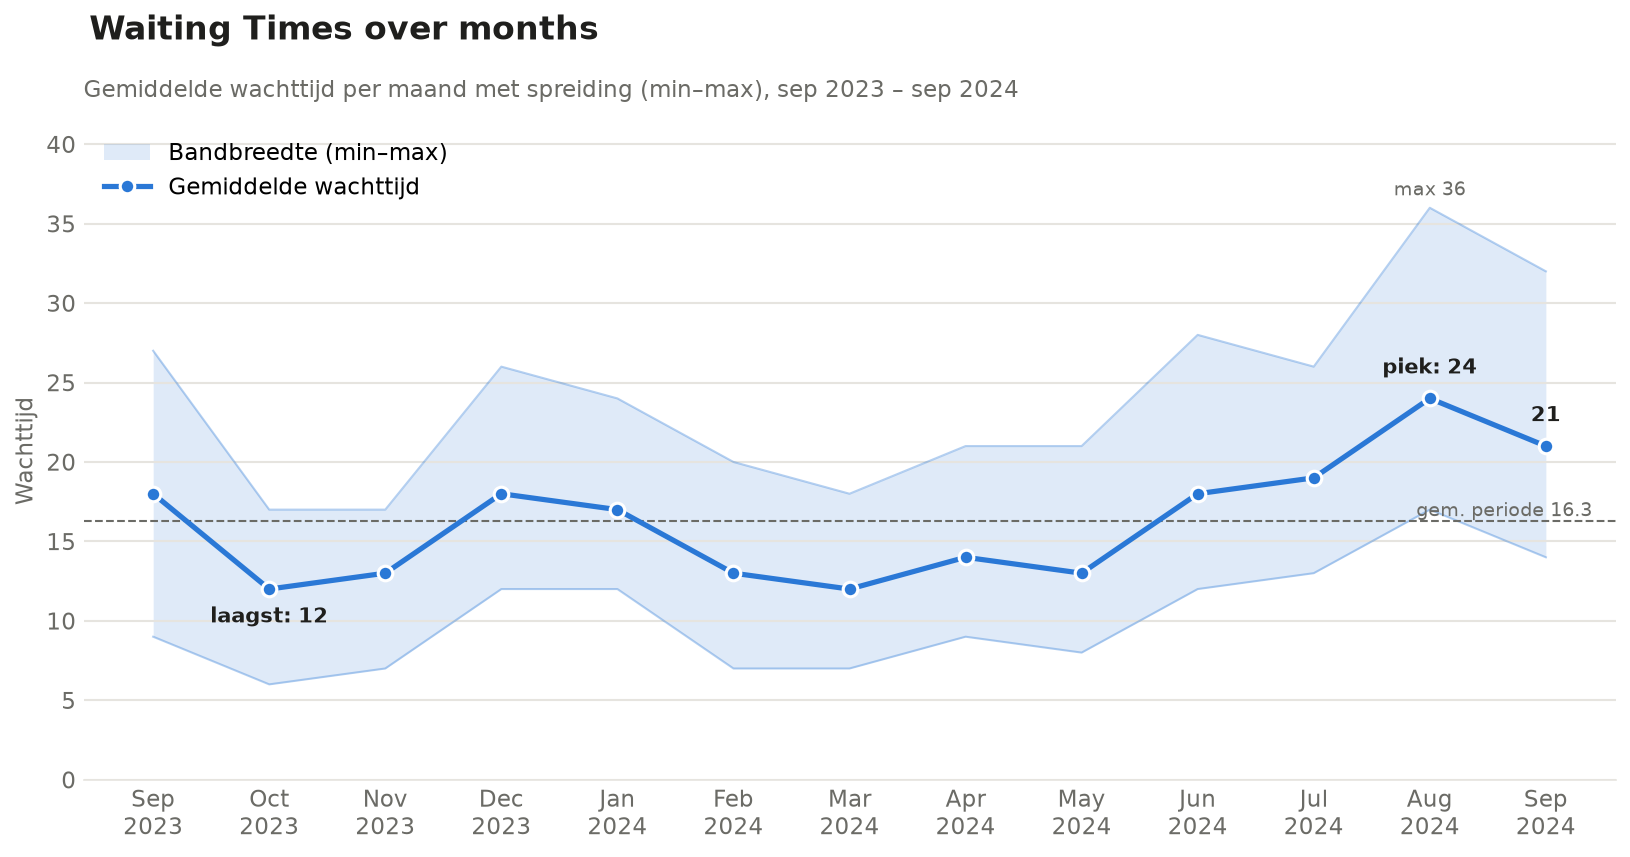

In [3]:
BLUE = '#2a78d6'
INK, MUTED, GRID = '#1f1f1d', '#6b6b66', '#e6e4df'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

x = range(len(df))
avg, lo, hi = df['Avg waiting time'], df['Min'], df['Max']

fig, ax = plt.subplots(figsize=(11, 5.8), dpi=150)

# Bandbreedte min–max
ax.fill_between(x, lo, hi, color=BLUE, alpha=0.15, linewidth=0, label='Bandbreedte (min–max)')
ax.plot(x, hi, color=BLUE, alpha=0.35, linewidth=1)
ax.plot(x, lo, color=BLUE, alpha=0.35, linewidth=1)

# Gemiddelde
ax.plot(x, avg, color=BLUE, linewidth=2.5, marker='o', markersize=7,
        markeredgecolor='white', markeredgewidth=1.5, label='Gemiddelde wachttijd', zorder=3)

# Periodegemiddelde als referentielijn
mean_all = avg.mean()
ax.axhline(mean_all, color=MUTED, linestyle='--', linewidth=1)
ax.text(len(df) - 0.6, mean_all, f'gem. periode {mean_all:.1f}', color=MUTED, va='bottom', ha='right', fontsize=9)

# Selectieve labels: laagste en hoogste gemiddelde + laatste maand
i_min, i_max, i_last = avg.idxmin(), avg.idxmax(), len(df) - 1
for i, txt, dy in [(i_min, f'laagst: {avg[i_min]}', -16), (i_max, f'piek: {avg[i_max]}', 12), (i_last, f'{avg[i_last]}', 12)]:
    ax.annotate(txt, (i, avg[i]), textcoords='offset points', xytext=(0, dy), ha='center',
                color=INK, fontsize=10, fontweight='bold')
ax.annotate(f'max {hi[i_max]}', (i_max, hi[i_max]), textcoords='offset points', xytext=(0, 6),
            ha='center', color=MUTED, fontsize=9)

# Opmaak
ax.set_xticks(list(x))
ax.set_xticklabels(df['Label'], color=MUTED)
ax.set_ylim(0, hi.max() * 1.15)
ax.set_ylabel('Wachttijd', color=MUTED)
ax.tick_params(colors=MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color(GRID)

fig.suptitle('Waiting Times over months', x=0.06, ha='left', fontsize=16, fontweight='bold', color=INK)
ax.set_title('Gemiddelde wachttijd per maand met spreiding (min–max), sep 2023 – sep 2024',
             loc='left', color=MUTED, fontsize=11, pad=12)
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('wachttijden.png', bbox_inches='tight', facecolor='white')
plt.show()

**Interpretatie:**
- De gemiddelde wachttijd schommelt in het najaar/voorjaar rond de 12–14, maar loopt vanaf juni 2024 duidelijk op naar een piek in **augustus 2024 (gem. 24, max 36)**.
- Ook de spreiding wordt in de zomer groter: niet alleen wachten mensen gemiddeld langer, de uitschieters worden ook extremer.
- December/januari laten een kleinere piek zien – mogelijk seizoensgebonden (feestdagen).
- Sep 2024 (21) ligt ruim boven sep 2023 (18): de trend is jaar-op-jaar gestegen.